# **Simple LinearnRegression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


In [ ]:
#sets the default figure size for all subsequent plots created using matplotlib. plt.rcParams
plt.rcParams['figure.figsize']=(20.0,10.0)

In [ ]:
from google.colab import files
import io
uploaded = files.upload()

# Read the specific file into a DataFrame
# Get the actual filename that was uploaded, as it might be renamed by Colab
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
df.head()

Saving headbrain.csv to headbrain (1).csv


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


# Linear Regression Basic Explination

**What is Linear Regression?**

---


Linear Regression is a fundamental statistical and machine learning algorithm used to predict a quantitative value (the Dependent Variable) based on one or more predictor values (the Independent Variables).

The core goal is to find a mathematical relationship—specifically a straight line—that best fits the data points. Once you have this line, you can use it to predict future outcomes. For example, in your Colab notebook, you are likely trying to predict Brain Weight based on Head Size.

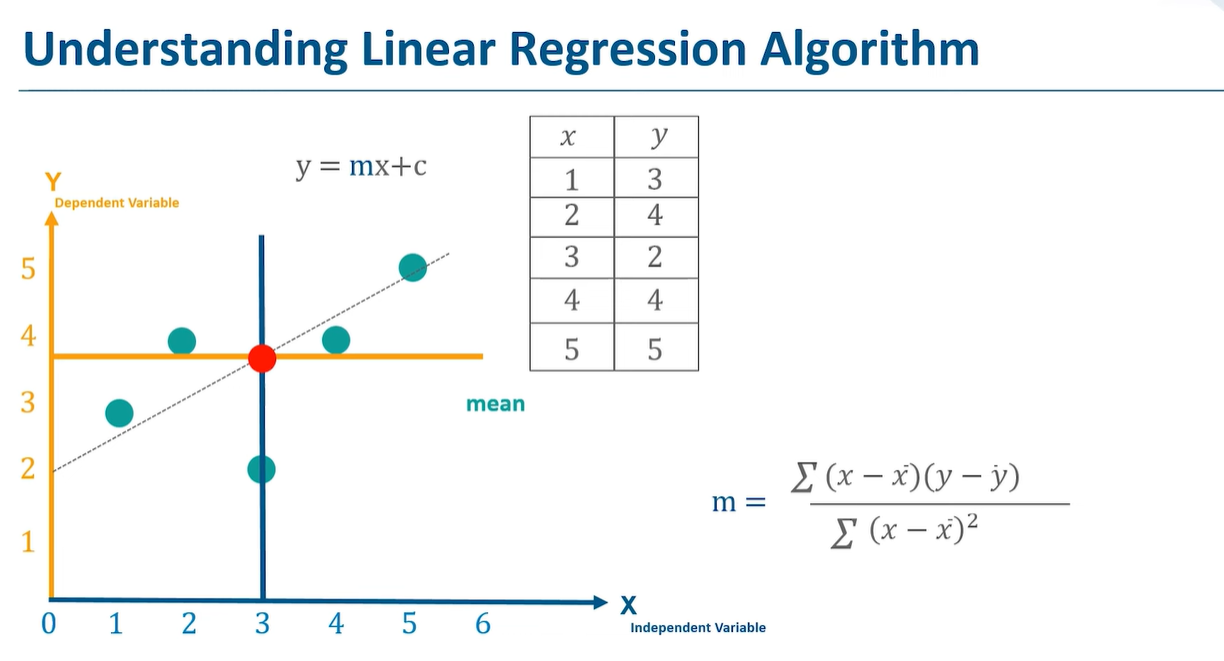

**How the Image Illustrates the Algorithm:**

---


The image shows the "Least Squares" method in action. Here is how it connects to the logic of the algorithm:Finding the Center: The algorithm first calculates the mean of $x$ and $y$ (represented by the intersecting blue and orange lines at the red dot).Calculating the Slope ($m$): Using the formula shown in the bottom right:$$m = \frac{\sum (x-\bar{x})(y-\bar{y})}{\sum (x-\bar{x})^2}$$This formula measures how much $y$ changes relative to $x$. If $m$ is positive (as it is in the image), it means as $x$ increases, $y$ also increases.Calculating the Intercept ($c$): Once you have $m$, you find $c$ (where the line hits the vertical axis) so the line perfectly balances the distances between all the teal dots.Prediction: Once the line is drawn, you can pick any $x$ value on the bottom axis, move up to the line, and look across to find the predicted $y$.

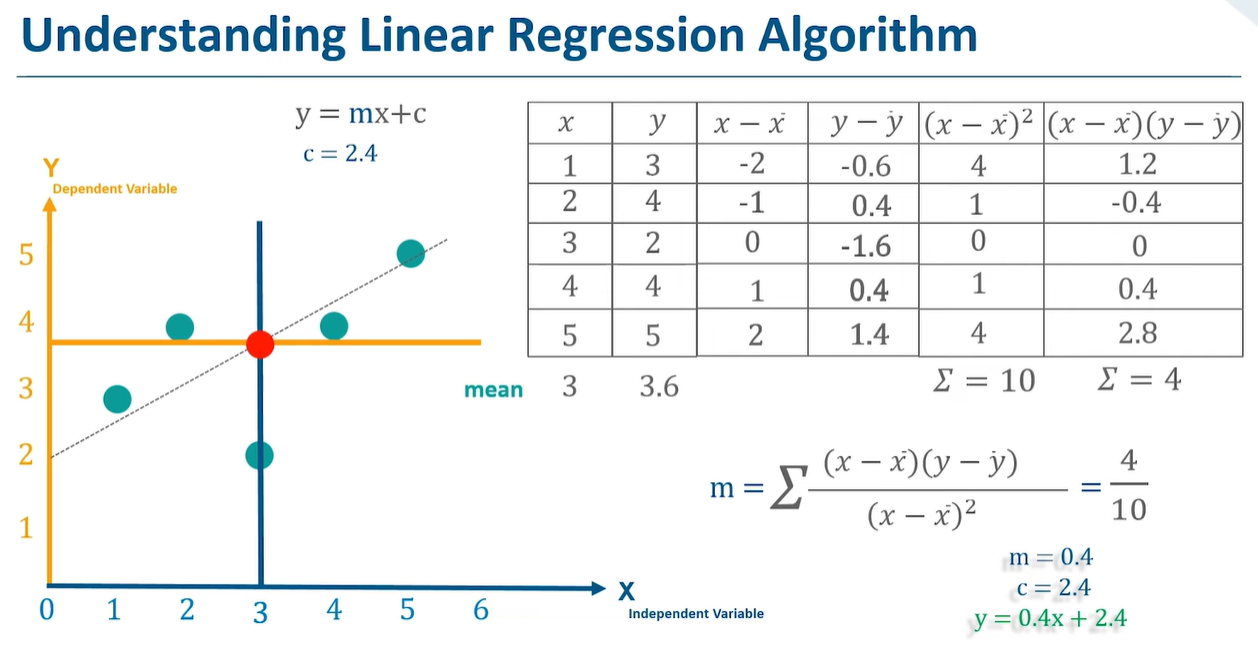

**Comparison: Image 1 vs. Image 2**


---
In moving from the first image to the second, you transitioned from Theory to Calculation.Step 1: You established the variables and the "best fit" line.Step 2: You solved for the Y-Intercept ($c$). By using the mean values of your data ($\bar{x} = 3$ and $\bar{y} = 3.6$) and the slope ($m$), you determined that when $x$ is zero, the starting value of $y$ is exactly $2.4$.


---


The Purpose of This Comparison

In ShortThe purpose is to show the process of parameter estimation. You are demonstrating how a generic mathematical formula ($y = mx + c$) becomes a specific predictive model ($y = mx + 2.4$) by finding the exact point where the line begins on the vertical axis.


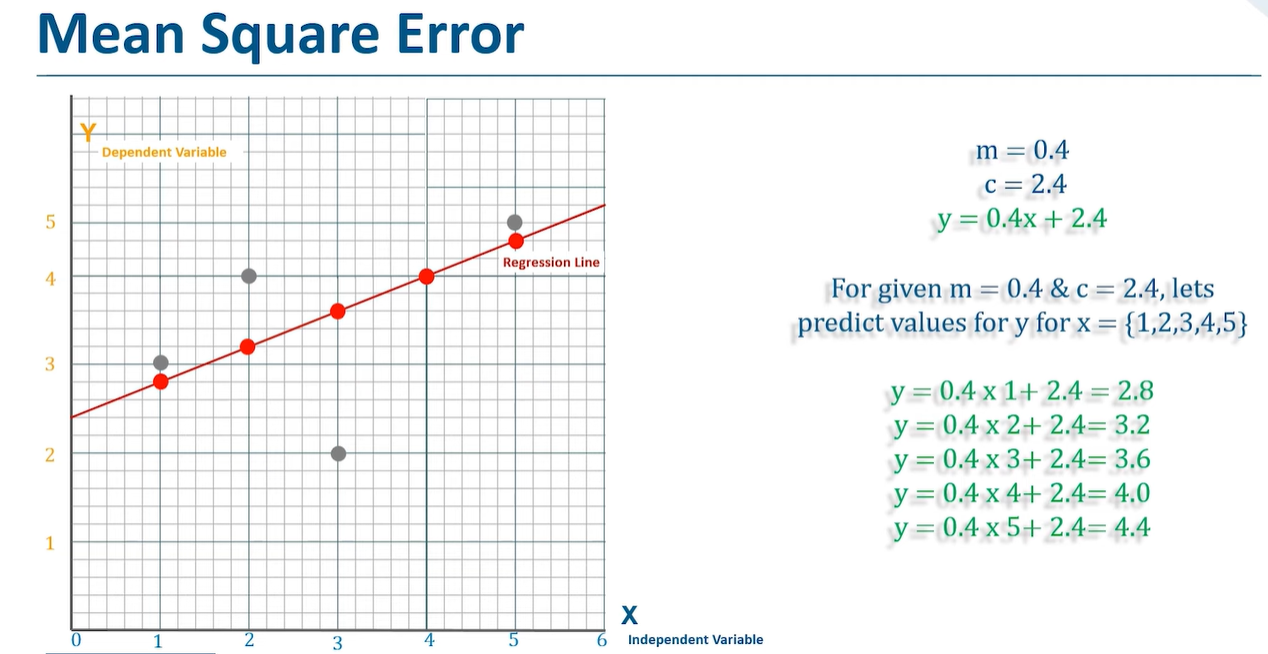

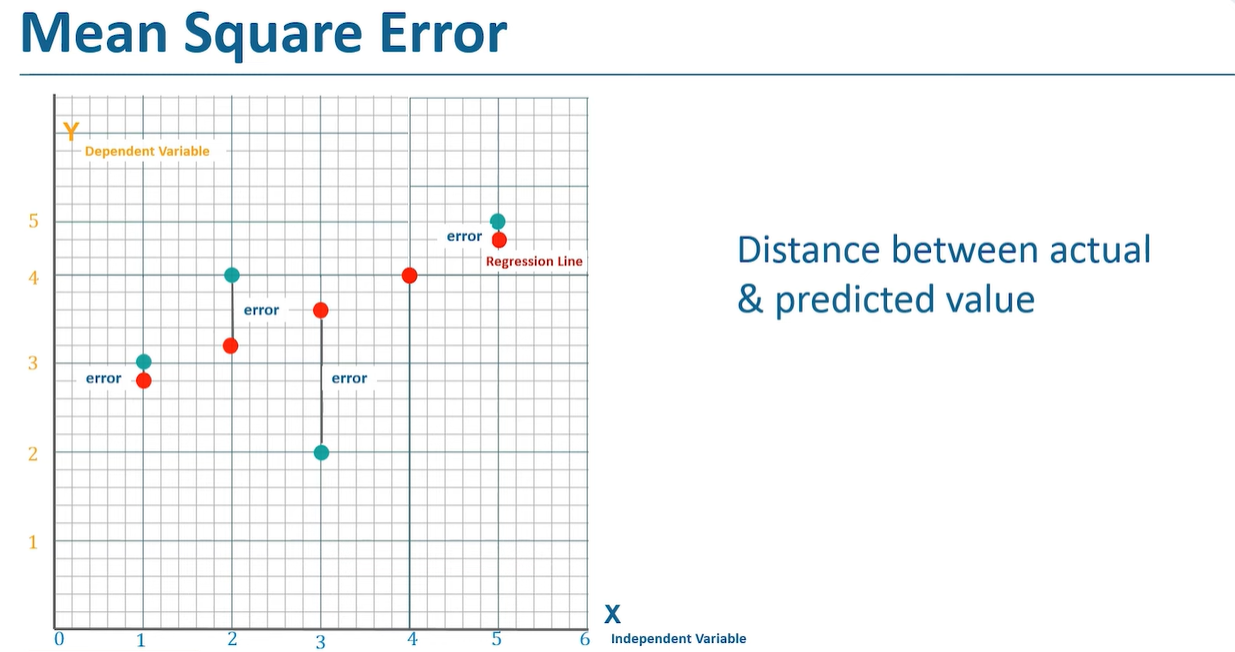

Calculation of $R^2$ Error

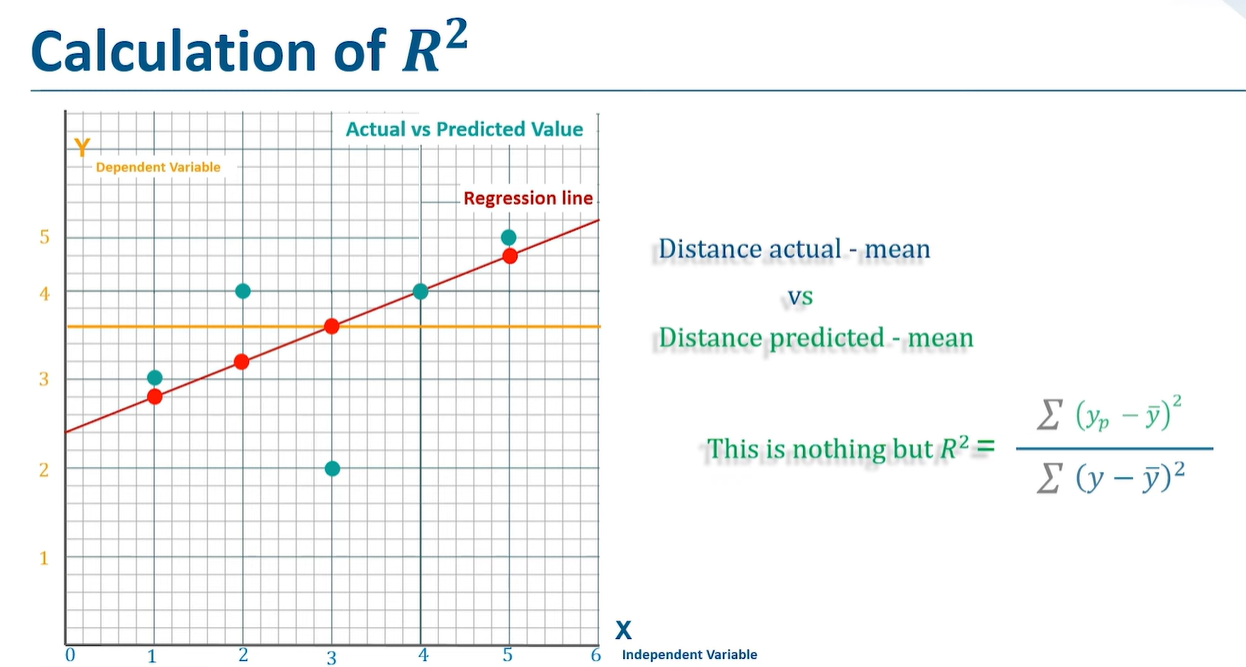

yp= y_predicted

$y^-$= mean

y= actual y

In [ ]:
#Univariate Linear Regression
x=df['Head Size(cm^3)'].values
y=df['Brain Weight(grams)'].values

In [ ]:
#mean and x & y
mean_x=np.mean(x)
mean_y=np.mean(y)

#total number of values
row=len(x)

#using the formula to calculate b1 and b0 or m and c
num=0
denom=0
for i in range(row):
  num+= (x[i]-mean_x)*(y[i]-mean_y)
  denom+= (x[i]-mean_x)**2
b1=num/denom
b0=mean_y - (b1*mean_x)

#coeff
print(b1, b0)

0.26342933948939945 325.57342104944223


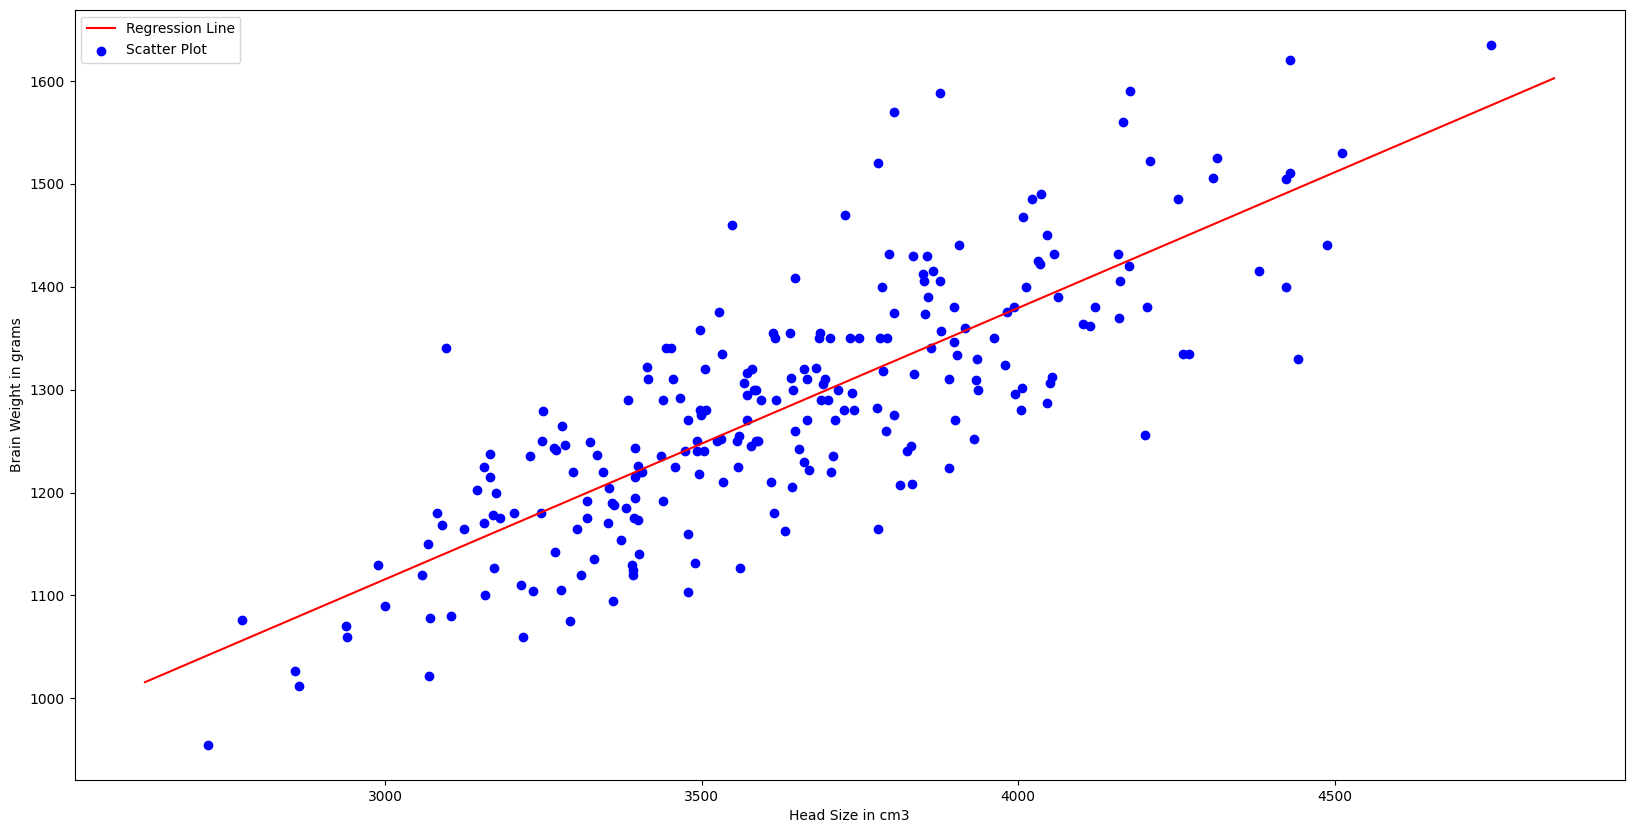

In [ ]:
# Re-extract the original data to make sure we have the actual data points
original_x = df['Head Size(cm^3)'].values
original_y = df['Brain Weight(grams)'].values

# Calculate x and y values for the regression line
max_x = np.max(original_x) + 100
min_x = np.min(original_x) - 100

x_line = np.linspace(min_x, max_x, 1000)
y_line = b0 + b1 * x_line

# Plotting the regression line
plt.plot(x_line, y_line, color='red', label='Regression Line')

# Plotting the actual scatter points from the dataset
plt.scatter(original_x, original_y, color='blue', label='Scatter Plot')

plt.xlabel('Head Size in cm3')
plt.ylabel('Brain Weight in grams')
plt.legend()
plt.show()

In [ ]:
ss_t = 0
ss_r = 0

for i in range(row):
  y_pred = b0 + b1 * original_x[i]
  ss_t += (original_y[i] - mean_y) ** 2
  ss_r += (original_y[i] - y_pred) ** 2

r2 = 1 - (ss_r / ss_t)
print(r2)

0.6393117199570003


# Implementing this using sklearn

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [ ]:
# Re-extract the original x data because the previous plot code set x to 1000 values
x = df['Head Size(cm^3)'].values

# Reshape to a 2D array (rank 2 matrix) for scikit-learn compatibility
x = x.reshape((row, 1))

In [ ]:
# Reset y to the original data values to match the length of x (237 samples)
y = df['Brain Weight(grams)'].values

# Creating and fitting the model
reg = LinearRegression()
reg = reg.fit(x, y)

In [ ]:
#y prediction
y_pred=reg.predict(x)


In [ ]:
#calculating RMSE & R2 sore
mse=mean_squared_error(y,y_pred)
rmse=np.sqrt(mse)
r2_score=reg.score(x,y)

print(np.sqrt(mse))
print(r2_score)

72.1206213783709
0.639311719957
